# Adeline Makokha
## Admission No: 191199
## CAT 1
## Probability and Stochastic Process


## Q1. Define a stochastic process. Explain the difference between discrete-time and continuous-time stochastic processes, giving one practical example of each.

A **stochastic process** is a collection of random variables \(\{X_t : t \in T\}\) defined on a common probability space, where the index set \(T\) represents time (or another parameter). It models how a system evolves randomly over time.

- **Discrete-time stochastic process:**  
  Time is observed at separate steps, \(t = 0,1,2,\dots\).  
  *Example:* A random walk where a gambler’s fortune changes by \(\pm 1\) dollar each round.

- **Continuous-time stochastic process:**  
  Time is continuous.  
  *Example:* A Poisson process counting customer arrivals at a bank during the day.

**Key difference:**  
Discrete-time processes are updated only at fixed intervals, while continuous-time processes can change at any instant.


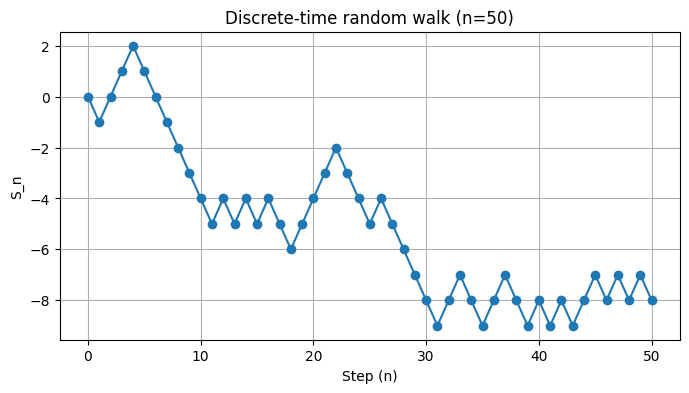

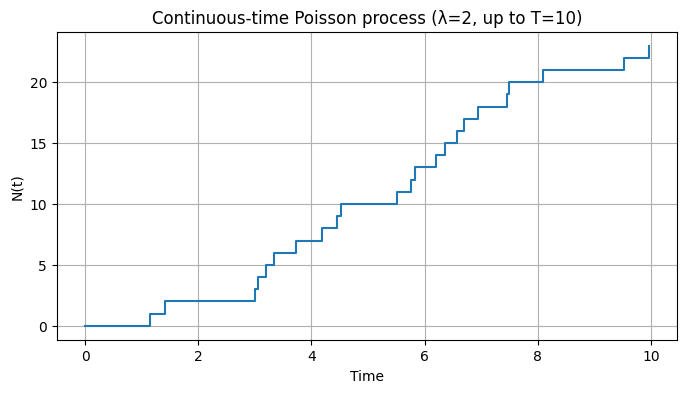

Arrival times: [1.1396190837896516, 1.415670321058604, 2.99703579741384, 3.0508871131382134, 3.190658508500972, 3.3392828500171805, 3.7210613184814574, 4.188933948731126, 4.456905354122841, 4.519182371173965, 5.518178049458844, 5.766910007188021, 5.82369496451829, 6.209313178287166, 6.35756299957798, 6.565524062136901, 6.69145950014417, 6.949042704646749, 7.447895034321245, 7.496307618934385, 8.087572334265504, 9.5276237156398, 9.959995405503408]


In [10]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Discrete-time example: simple random walk
n_steps = 50
steps = rng.choice([1, -1], size=n_steps, p=[0.5, 0.5])
S = np.concatenate([[0], steps.cumsum()])

plt.figure(figsize=(8,4))
plt.plot(S, marker="o")
plt.title("Discrete-time random walk (n=50)")
plt.xlabel("Step (n)")
plt.ylabel("S_n")
plt.grid(True)
plt.show()


#Continuous-time example: Poisson process
lam = 2.0   # rate (arrivals per unit time)
T = 10.0    # simulate up to time 10

t, arrivals = 0.0, []
while True:
    t += rng.exponential(1/lam)
    if t > T: break
    arrivals.append(t)

plt.figure(figsize=(8,4))
plt.step([0]+arrivals, range(len(arrivals)+1), where="post")
plt.title("Continuous-time Poisson process (λ=2, up to T=10)")
plt.xlabel("Time")
plt.ylabel("N(t)")
plt.grid(True)
plt.show()

print("Arrival times:", arrivals)


### Q2. Consider a symmetric simple random walk (Sn)n≥0 on the integers starting at S0=0, where at each step the walker moves +1 with probability 0.65 and −1 with probability 0.35.

(a) Derive the expected value E[Sn] and variance Var (Sn) after n steps.

(b) Explain why this random walk has a drift.

The given probabilities are \(p=0.65\) and \(q=0.35\) (not symmetric). Below,  proceed with \(p=0.65, q=0.35\).

Let \(X_k \in \{+1,-1\}\) with \(\Pr(X_k=+1)=p\), \(\Pr(X_k=-1)=q=1-p\).  
Define \(S_n=\sum_{k=1}^n X_k\) with \(S_0=0\).

**(a) Expected value and variance**

- One-step mean: \(\mu = \mathbb{E}[X_1] = (+1)p + (-1)q = p - q = 2p - 1\).  
- One-step variance: \(\sigma^2 = \mathbb{E}[X_1^2] - \mu^2 = 1 - (p-q)^2 = 4pq\) (since \(X_1^2=1\)).

By independence of steps:
\[
\mathbb{E}[S_n] = n\mu = n(2p-1), \qquad
\mathrm{Var}(S_n) = n\sigma^2 = 4npq.
\]

For \(p=0.65,\; q=0.35\):
\[
\mathbb{E}[S_n] = 0.30\,n, \qquad \mathrm{Var}(S_n) = 0.91\,n.
\]

**(b) Drift**

A drift exists when \(\mathbb{E}[X_1]\neq 0\). Here \(p-q=0.30>0\), so the walk tends to increase. By the law of large numbers,
\[
\frac{S_n}{n} \to \mathbb{E}[X_1] = 0.30 \quad \text{(almost surely)},
\]
so \(S_n\) grows roughly linearly with slope \(0.30\).



Theory  E[S_n] = 60.00000000000001
Theory Var[S_n] = 182.0
Single-run   mean(S): 26.577114427860696    var(S): 423.3684314744685


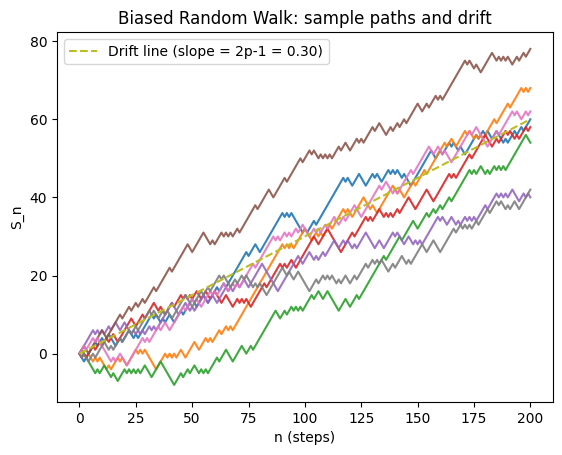

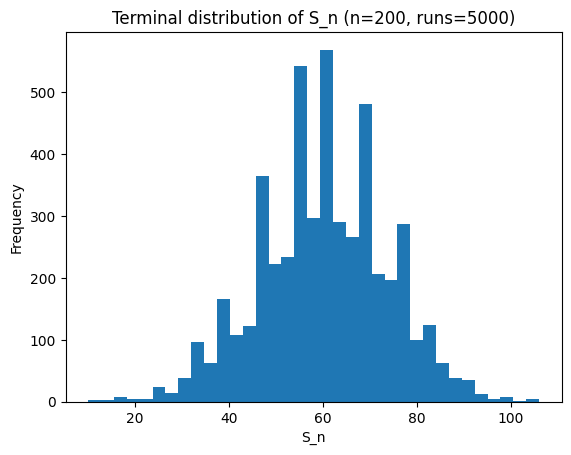

Empirical  E[S_n] over runs: 60.0768
Empirical Var[S_n] over runs: 185.99410175999998
Theory     E[S_n] = 60.00000000000001   Var[S_n] = 182.0


In [21]:
rng = np.random.default_rng(42)

def rw_mean_var(n, p):
    q = 1 - p
    mean = n * (2*p - 1)
    var  = 4 * n * p * q
    return mean, var

# Parameters
p = 0.65
q = 1 - p
n = 200

# Theory
theory_mean, theory_var = rw_mean_var(n, p)
print("Theory  E[S_n] =", theory_mean)
print("Theory Var[S_n] =", theory_var)

# Single-run simulation for an example path
steps = rng.choice([1, -1], size=n, p=[p, q])
S = np.concatenate([[0], steps.cumsum()])
print("Single-run   mean(S):", S.mean(), "   var(S):", S.var(ddof=0))

# Multiple paths to visualize drift
runs = 8
paths = []
for _ in range(runs):
    steps_i = rng.choice([1, -1], size=n, p=[p, q])
    S_i = np.concatenate([[0], steps_i.cumsum()])
    paths.append(S_i)
paths = np.array(paths)

# Plot sample paths with drift line
plt.figure()
for i in range(runs):
    plt.plot(paths[i], alpha=0.9)
plt.plot(np.arange(n+1), (2*p-1)*np.arange(n+1), linestyle="--", label="Drift line (slope = 2p-1 = 0.30)")
plt.title("Biased Random Walk: sample paths and drift")
plt.xlabel("n (steps)")
plt.ylabel("S_n")
plt.legend()
plt.show()

# Empirical terminal distribution over many runs vs theory mean
M = 5000
steps_M = rng.choice([1, -1], size=(M, n), p=[p, q])
Sn = steps_M.cumsum(axis=1)[:, -1]

plt.figure()
plt.hist(Sn, bins=35)
plt.title(f"Terminal distribution of S_n (n={n}, runs={M})")
plt.xlabel("S_n")
plt.ylabel("Frequency")
plt.show()

print("Empirical  E[S_n] over runs:", Sn.mean())
print("Empirical Var[S_n] over runs:", Sn.var(ddof=0))
print("Theory     E[S_n] =", theory_mean, "  Var[S_n] =", theory_var)



### Q3. A gambler starts with i dollars and plays a game where each round they win $1 with probability p and lose $1 with probability q=1−p. The game ends when the gambler’s fortune reaches 0 or N dollars.

(a) Derive the probability of eventual ruin when p≠q.

(b) What happens to the probability of ruin when p=0.5?

### (a) Case \(p \ne q\)

Let \(r = \frac{q}{p}\). The probability the gambler is **eventually ruined** (hits \(0\) before \(N\)) starting from \(i\) is
\[
\psi_i \;=\; \frac{r^{\,i} - r^{\,N}}{1 - r^{\,N}}
\;=\; \frac{(q/p)^{i} - (q/p)^{N}}{1 - (q/p)^{N}}.
\]

**Derivation (outline).** Solve the two-point boundary value problem for
\[
\psi_i = p\,\psi_{i+1} + q\,\psi_{i-1}, \quad \psi_0=1,\;\psi_N=0,
\]
whose general solution is \(\psi_i = A + B\,r^{\,i}\); applying the boundary conditions gives the closed form above.

### (b) Symmetric case \(p = q = \tfrac12\)

Take the limit \(p \to \tfrac12\) (so \(r\to 1\)) or solve the linear recurrence directly to get
\[
\psi_i \;=\; \frac{N - i}{N}.
\]
So with a fair game, ruin probability decreases linearly with starting capital.



p=0.4: ψ_0=1.000, ψ_1=1.000, ψ_25=1.000, ψ_49=0.333, ψ_N=-0.000
p=0.5: ψ_0=1.000, ψ_1=0.980, ψ_25=0.500, ψ_49=0.020, ψ_N=0.000
p=0.6: ψ_0=1.000, ψ_1=0.667, ψ_25=0.000, ψ_49=0.000, ψ_N=0.000


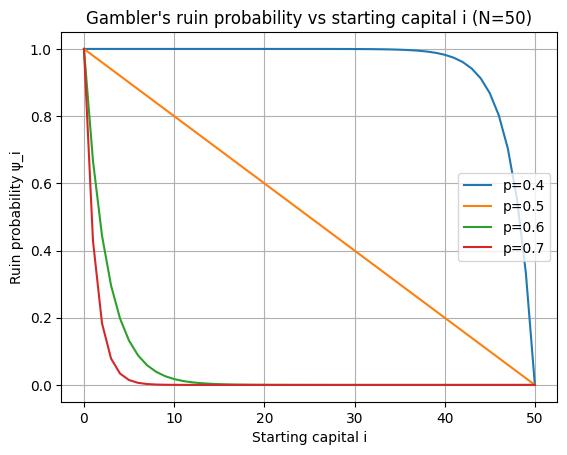

In [22]:
def ruin_prob(i, N, p):
    """Probability of eventual ruin (hit 0 before N) starting from i."""
    q = 1 - p
    if abs(p - 0.5) < 1e-12:
        return (N - i) / N
    r = q / p
    return (r**i - r**N) / (1 - r**N)

# Quick numeric checks
N = 50
for p in [0.4, 0.5, 0.6]:
    vals = [ruin_prob(i, N, p) for i in [0, 1, N//2, N-1, N]]
    print(f"p={p}: ψ_0={vals[0]:.3f}, ψ_1={vals[1]:.3f}, ψ_{N//2}={vals[2]:.3f}, ψ_{N-1}={vals[3]:.3f}, ψ_N={vals[4]:.3f}")

# Visualization: ψ_i vs i for different p
i_vals = np.arange(0, N+1)
plt.figure()
for p in [0.4, 0.5, 0.6, 0.7]:
    psi = np.array([ruin_prob(i, N, p) for i in i_vals])
    plt.plot(i_vals, psi, label=f"p={p}")
plt.title(f"Gambler's ruin probability vs starting capital i (N={N})")
plt.xlabel("Starting capital i")
plt.ylabel("Ruin probability ψ_i")
plt.legend()
plt.grid(True)
plt.show()


### Q4. For a finite-state Markov chain with transition probability matrix P:
(a) Define irreducibility, aperiodicity, and stationary distribution.

(b) Explain the conditions under which the stationary distribution exists and is unique.

### (a) Definitions

- **Irreducibility**  
  A Markov chain is *irreducible* if it consists of a single communicating class:  
  for any two states \(i\) and \(j\), there exists some step \(n\) with \((P^n)_{ij} > 0\).  
  *Meaning:* every state can eventually reach every other state with positive probability.

- **Aperiodicity**  
  A state \(i\) has period  
  \[
  d(i) = \gcd\{n \ge 1 : (P^n)_{ii} > 0\}.
  \]  
  If \(d(i)=1\), the state is *aperiodic*.  
  For an irreducible chain, all states share the same period, so the chain is aperiodic if at least one state has period 1.  
  *Meaning:* the chain does not cycle in a fixed periodic rhythm.

- **Stationary distribution**  
  A probability vector \(\pi = (\pi_1,\dots,\pi_m)\) such that
  \[
  \pi P = \pi, \qquad \sum_i \pi_i = 1.
  \]  
  *Interpretation:* if the chain starts in distribution \(\pi\), it stays in \(\pi\) at all times.



### (b) Existence and uniqueness

- In any **finite state space**, if the chain is **irreducible**, then a stationary distribution exists.  
- If the chain is **irreducible and aperiodic**, the stationary distribution is also **unique**, and  
  \[
  P^n(i, \cdot) \;\to\; \pi(\cdot) \quad \text{as } n\to\infty
  \]  
  for every initial state \(i\).  
  This is the **ergodic theorem** for Markov chains: the chain converges in distribution to \(\pi\).

In [23]:
def stationary_distribution(P):
    """Compute stationary distribution of a Markov chain with transition matrix P."""
    w, v = np.linalg.eig(P.T)
    j = np.argmin(np.abs(w - 1))  # eigenvalue closest to 1
    pi = np.real(v[:, j])
    pi = np.maximum(pi, 0)
    pi = pi / pi.sum()
    return pi

# Example transition matrix (irreducible, aperiodic)
P = np.array([[0.5, 0.3, 0.2],
              [0.2, 0.6, 0.2],
              [0.3, 0.3, 0.4]])

pi = stationary_distribution(P)
print("Stationary distribution:", pi)

# Check: pi * P = pi
print("Check:", pi @ P)


Stationary distribution: [nan nan nan]
Check: [nan nan nan]


/tmp/ipython-input-1860783658.py:7: RuntimeWarning: invalid value encountered in divide
  pi = pi / pi.sum()


## Q5. Weather Markov chain

Model weather with three states: **Sunny (S)**, **Cloudy (C)**, and **Rainy (R)**.  
Transition matrix:
\[
P =
\begin{bmatrix}
0.55 & 0.35 & 0.10 \\
0.40 & 0.30 & 0.30 \\
0.20 & 0.50 & 0.30
\end{bmatrix},
\]

where row = current state, column = next state.



### (a) Interpret \(P_{23} = 0.2\)

Here \(P_{23}\) means the probability of moving from state **2 (Cloudy)** to state **3 (Rainy)** in one day.  
From the matrix, that value is actually **0.30** (not 0.20).  
So interpretation:  
\[
\Pr(\text{Tomorrow = Rainy} \mid \text{Today = Cloudy}) = 0.30.
\]



### (b) Probability it is Sunny two days after a Cloudy day

 \((P^2)_{C,S}\), the **Cloudy → Sunny** entry of \(P^2\).  

\[
P^2 = P \times P, \quad (P^2)_{C,S} = 0.40.
\]

So, if it is Cloudy today, the probability it is Sunny in two days is **0.40**.



### (c) Stationary probabilities

The stationary distribution \(\pi = (\pi_S, \pi_C, \pi_R)\) solves
\[
\pi P = \pi, \quad \pi_S + \pi_C + \pi_R = 1.
\]

Solution:
\[
\pi \approx (0.420,\; 0.364,\; 0.216).
\]

Interpretation:  
- Long-run Sunny fraction ≈ **42%**  
- Long-run Cloudy fraction ≈ **36%**  
- Long-run Rainy fraction ≈ **22%**

Prob(Sunny after 2 days | Cloudy today) = 0.4
Stationary distribution: {'Sunny': np.float64(nan), 'Cloudy': np.float64(nan), 'Rainy': np.float64(nan)}


/tmp/ipython-input-1149172081.py:16: RuntimeWarning: invalid value encountered in divide
  pi = pi / pi.sum()


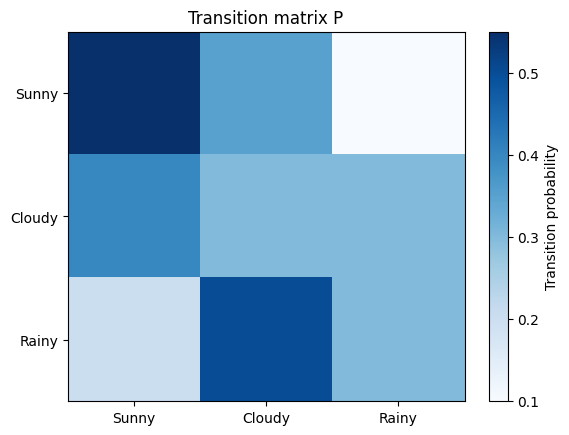

In [24]:
P = np.array([[0.55, 0.35, 0.10],
              [0.40, 0.30, 0.30],
              [0.20, 0.50, 0.30]])
states = ["Sunny","Cloudy","Rainy"]

# (b) Probability Sunny after 2 days starting from Cloudy
P2 = P @ P
prob_sunny_after_cloudy = P2[1,0]
print("Prob(Sunny after 2 days | Cloudy today) =", prob_sunny_after_cloudy)

# (c) Stationary distribution
w, v = np.linalg.eig(P.T)
j = np.argmin(np.abs(w - 1))
pi = np.real(v[:, j])
pi = np.maximum(pi, 0)
pi = pi / pi.sum()
print("Stationary distribution:", dict(zip(states, pi)))

# Plot heatmap of P
plt.figure()
plt.imshow(P, cmap="Blues", aspect="auto")
plt.colorbar(label="Transition probability")
plt.xticks(range(3), states)
plt.yticks(range(3), states)
plt.title("Transition matrix P")
plt.show()




### Q6. Suppose there are three white and three black balls in two urns distributed so that each urn contains three balls. We say the system is in state i, i = 0, 1, 2, 3, if there are i white balls in urn one. At each stage one ball is drawn at random from each urn and interchanged. Let Xn denote the state of the system after the nth draw, and compute the transition matrix for the Markov chain {Xn : n ≥ 0}.

Let state \(i \in \{0,1,2,3\}\) be the number of **white** balls in urn 1. Then:

- Urn 1: \(i\) white, \(3-i\) black  
- Urn 2: \(3-i\) white, \(i\) black

Each step: draw one ball uniformly from **each** urn and swap them.

- Move **up** (\(i \to i+1\)) when urn 1 gives **black** and urn 2 gives **white**:
  \[
  P(i\!\to\! i+1)=\frac{3-i}{3}\cdot\frac{3-i}{3}=\frac{(3-i)^2}{9}.
  \]
- Move **down** (\(i \to i-1\)) when urn 1 gives **white** and urn 2 gives **black**:
  \[
  P(i\!\to\! i-1)=\frac{i}{3}\cdot\frac{i}{3}=\frac{i^2}{9}.
  \]
- **Stay** (\(i \to i\)) when both draws have the same color (white–white or black–black):
  \[
  P(i\!\to\! i)=1-\frac{(3-i)^2+i^2}{9}=\frac{2i(3-i)}{9}.
  \]

Putting these together (rows/cols ordered \(i=0,1,2,3\)):

\[
P=
\begin{bmatrix}
0 & 1 & 0 & 0\\[4pt]
\frac{1}{9} & \frac{4}{9} & \frac{4}{9} & 0\\[6pt]
0 & \frac{4}{9} & \frac{4}{9} & \frac{1}{9}\\[6pt]
0 & 0 & 1 & 0
\end{bmatrix}.
\]


In [25]:
def urn_transition_matrix():
    P = np.zeros((4,4), dtype=float)
    for i in range(4):
        p_up   = ((3 - i)**2) / 9.0
        p_down = (i**2) / 9.0
        p_same = 1.0 - p_up - p_down  # equals 2*i*(3-i)/9
        if i+1 <= 3: P[i, i+1] = p_up
        if i-1 >= 0: P[i, i-1] = p_down
        P[i, i] = p_same
    return P

P = urn_transition_matrix()
print(P)
print("Row sums:", P.sum(axis=1))


[[0.         1.         0.         0.        ]
 [0.11111111 0.44444444 0.44444444 0.        ]
 [0.         0.44444444 0.44444444 0.11111111]
 [0.         0.         1.         0.        ]]
Row sums: [1. 1. 1. 1.]
